# Raw Data Inspection

Visualisation of the raw (uncorrected) complex visibility $V(\nu, h)$ from all observation chips, plotted against hour angle. Each chip is shown in a distinct colour to reveal gain variations, temporal gaps, and the fringe structure before any preprocessing.

The IF chain configuration (sky band $10.29\text{–}10.54\;\mathrm{GHz}$, 250 MHz total bandwidth, $N_{\rm FFT} = 2048$ channels of $\Delta\nu = 244\;\mathrm{kHz}$ each) and the bad-channel list `(0, 256, 512, 768)` (DC bin and FPGA pipeline harmonics at multiples of 256) are documented in the [AY 121 Lab 3 manual](../REFERENCES.md) (`[AY121-Lab3]`).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    BAD_CHANNELS, SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
# --- Load data ---
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr           # (N_cap, N_CH) complex — raw visibility
corr_std    = captures.corr_std       # (N_cap, N_CH) float
ha_deg_arr  = chip_data.ha_deg        # (N_cap,) hour angle in degrees
F_SKY_GHZ   = chip_data.f_sky_ghz    # (N_CH,)
chip_slices = chip_data.chip_slices
N_chips     = len(chip_slices)

# Analysis band mask (good channels inside the IF passband)
band_mask = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False

# Band-averaged raw visibility per capture
corr_band = corr_raw[:, band_mask]   # (N_cap, N_band_ch) complex

print(f"Captures: {corr_raw.shape[0]},  Channels: {corr_raw.shape[1]}")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f}–{PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Chips: {N_chips}  ({[sl.stop - sl.start for sl in chip_slices]} captures)")

Captures: 8226,  Channels: 1024
Analysis band: 10.415–10.485 GHz  (285 channels)
Chips: 3  ([5514, 403, 2309] captures)


## Raw visibility vs hour angle (representative channel)

Each panel shows the raw complex visibility at a single representative channel near the band centre, as a function of hour angle. Chips are overlaid in different colours. No DC correction has been applied — the DC pedestal is visible in the real part as a slowly-varying offset from zero.

/tmp/ipykernel_2948/3807424851.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


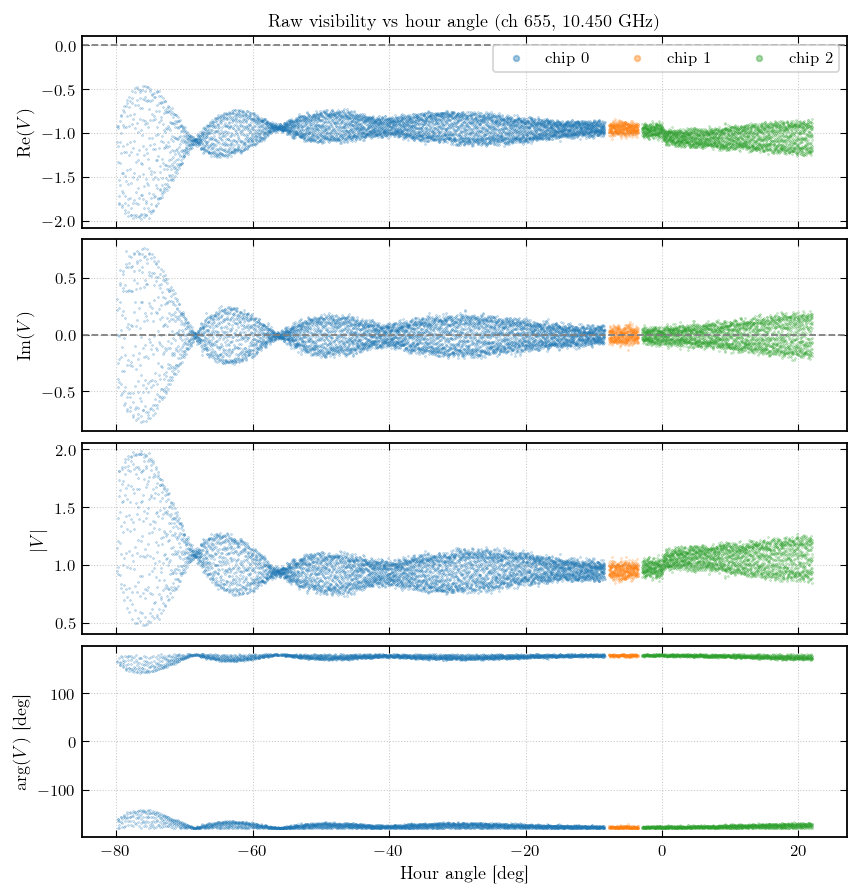

In [3]:
# --- Chip colours ---
CHIP_COLORS = COMPONENT_COLORS[:N_chips]

# --- Representative single channel (mid-band) ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_ch = corr_raw[:, k_mid]

ch_real  = vis_ch.real
ch_imag  = vis_ch.imag
ch_amp   = np.abs(vis_ch)
ch_phase = np.angle(vis_ch, deg=True)

# --- Four-panel plot ---
fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V)$", r"Im$(V)$", r"$|V|$", r"$\arg(V)$ [deg]"]
data   = [ch_real, ch_imag, ch_amp, ch_phase]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ha_chip = ha_deg_arr[sl]
        y_chip  = y[sl]
        ax.scatter(ha_chip, y_chip, s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title(f"Raw visibility vs hour angle (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Per-channel waterfall: single representative channel

To see the fringe oscillation clearly without band-averaging, we plot the raw visibility at a single channel near the band centre.

/tmp/ipykernel_2948/1428818119.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


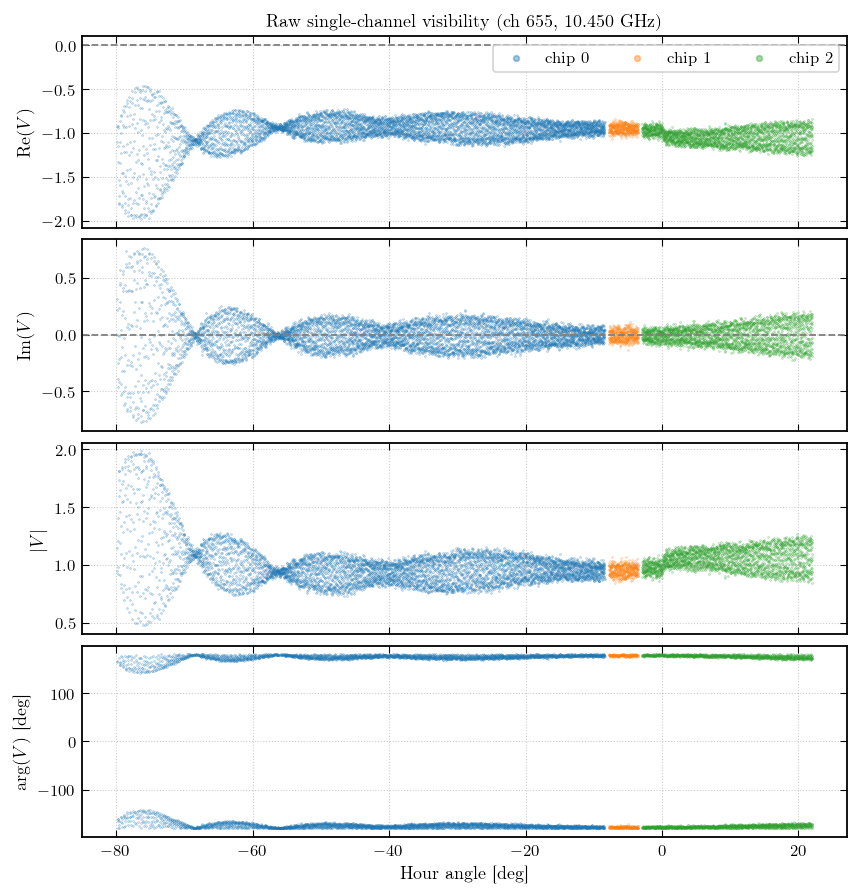

In [4]:
# --- Single-channel view at band centre ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_ch = corr_raw[:, k_mid]

ch_real  = vis_ch.real
ch_imag  = vis_ch.imag
ch_amp   = np.abs(vis_ch)
ch_phase = np.angle(vis_ch, deg=True)

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V)$", r"Im$(V)$", r"$|V|$", r"$\arg(V)$ [deg]"]
data   = [ch_real, ch_imag, ch_amp, ch_phase]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title(f"Raw single-channel visibility (ch {k_mid}, {f_mid_ghz:.3f} GHz)",
                  fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Raw amplitude spectrum

Time-averaged amplitude spectrum across the full 250 MHz Nyquist band ($N_{\rm FFT} = 2048$ channels of $\Delta\nu = F_S/N_{\rm FFT} \approx 244\;\mathrm{kHz}$, configured per the IF chain documented in [AY121-Lab3]), per chip. This shows the IF bandpass shape, the bad channels (spikes at DC/FPGA harmonics), and the usable analysis band.

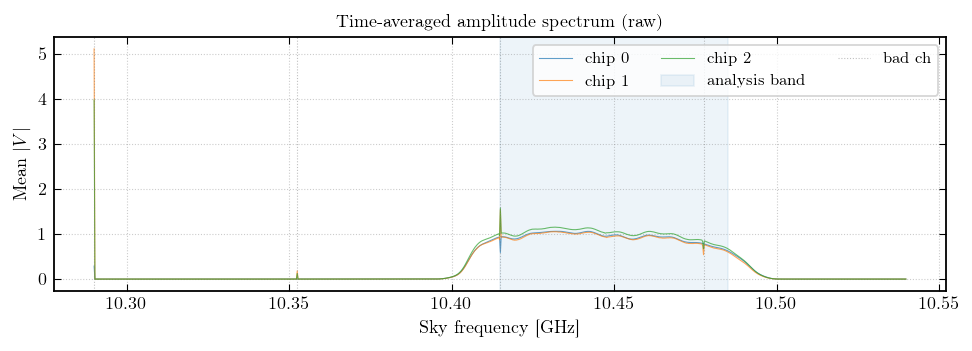

In [5]:
# --- Time-averaged amplitude spectrum per chip ---
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))

for ci, sl in enumerate(chip_slices):
    mean_amp = np.nanmean(np.abs(corr_raw[sl]), axis=0)
    ax.plot(F_SKY_GHZ, mean_amp, lw=LW_FINE, color=CHIP_COLORS[ci],
            alpha=0.7, label=f"chip {ci}")

# Mark analysis band
ax.axvspan(PLOT_BAND_GHZ[0], PLOT_BAND_GHZ[1], alpha=0.08, color="C0",
           label="analysis band")

# Mark bad channels
for bc in BAD_CHANNELS:
    ax.axvline(F_SKY_GHZ[bc], color=NEUTRAL_COLOR, lw=LW_FINE, ls=":", alpha=0.5,
               label="bad ch" if bc == BAD_CHANNELS[0] else None)

ax.set_xlabel("Sky frequency [GHz]")
ax.set_ylabel("Mean $|V|$")
ax.set_title("Time-averaged amplitude spectrum (raw)", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE - 1, ncol=3)
fig.tight_layout()
plt.show()

## Observation timeline and cadence

Capture timestamps and inter-capture gaps to visualise the temporal structure of the observation: continuous tracking segments, chip boundaries, and integration cadence.

/tmp/ipykernel_2948/4216422811.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


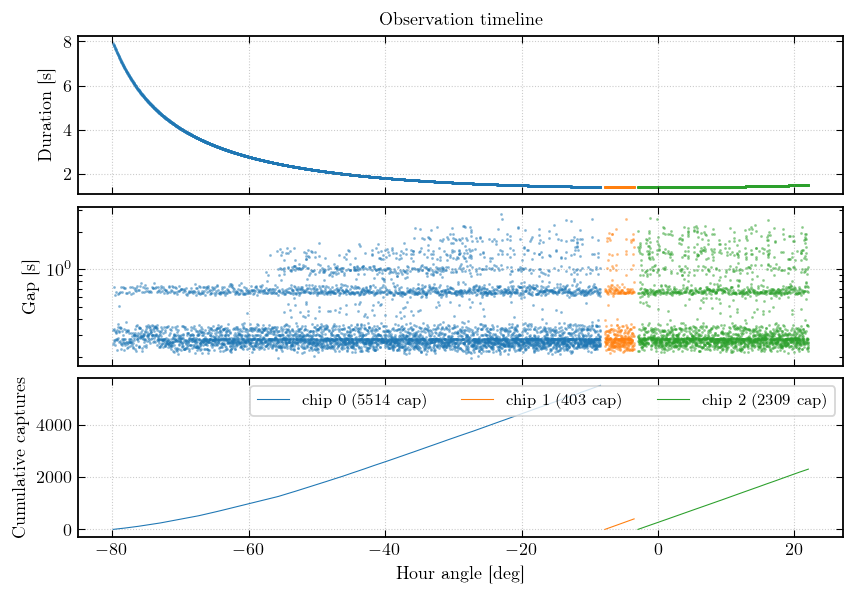

Median gap (end-to-start): 0.28 s
Median integration: 1.51 s


In [6]:
# --- Timeline and cadence ---
unix_mid = captures.unix_mid
duration = captures.duration_sec
# Gap = start of next capture minus end of previous capture (dead time between integrations)
gaps = captures.unix_time_start[1:] - captures.unix_time_end[:-1]

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.0), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Integration duration
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], duration[sl], s=0.3, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True)
axes[0].set_ylabel("Duration [s]")
axes[0].set_title("Observation timeline", fontsize=TICK_SIZE)

# (b) Inter-capture gap (end-to-start dead time)
for ci, sl in enumerate(chip_slices):
    idx = slice(sl.start, sl.stop - 1)
    axes[1].scatter(ha_deg_arr[idx], gaps[idx], s=0.3, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True)
axes[1].set_ylabel("Gap [s]")
axes[1].set_yscale("log")

# (c) Cumulative captures
for ci, sl in enumerate(chip_slices):
    n = sl.stop - sl.start
    axes[2].plot(ha_deg_arr[sl], np.arange(n), lw=LW_FINE, color=CHIP_COLORS[ci],
                 label=f"chip {ci} ({n} cap)")
axes[2].set_ylabel("Cumulative captures")
axes[2].set_xlabel("Hour angle [deg]")
axes[2].legend(fontsize=TICK_SIZE - 1, ncol=N_chips)

fig.tight_layout()
plt.show()

print(f"Median gap (end-to-start): {np.median(gaps[gaps < 10]):.2f} s")
print(f"Median integration: {np.median(duration):.2f} s")

## Summary statistics, noise estimate, and chip-gain check

The per-chip table below reports captures, hour-angle range, cadence, and median band-averaged $|V|$. Two things to look for:

1. **A per-capture noise estimate** $\hat\sigma_V$, computed as the across-channel scatter of $|V|$ inside the 70 MHz analysis band, divided by $\sqrt{N_{\mathrm{ch}}}$. This is the noise model used downstream by the diameter and baseline fits (the radiometer-equation context is in §1.7b of the theory notebook; the canonical reference is the radiometer equation of [R&W] §4.1 or [TMS3] §6.2).
2. **A chip-to-chip gain check.** The median $|V|$ in the analysis band should be (approximately) the same in all chips, since the source flux and the antenna gains are nominally constant on the timescale of one observation. A jump between chips of more than a few percent indicates an unmodelled gain step (back-end re-tune, attenuator change, gain drift) that — if uncorrected — will look like a real fringe feature in the diameter and sunspot fits and must be flagged. (No published reference quantifies this for the NCH back-end; the value is empirical, and the inflation it introduces in the §8.1 budget of nb 05 is bracketed.)


In [7]:
# --- Per-chip summary, noise estimate, and gain check ---
print(f"{'Chip':>6} {'N_cap':>7} {'HA range [deg]':>20} {'Med cadence [s]':>16} "
      f"{'Med |V|':>10} {'sigma_V':>10}")
print("-" * 78)
chip_med_amp = []
chip_sigma_V = []
for ci, sl in enumerate(chip_slices):
    n = sl.stop - sl.start
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    cad = np.median(np.diff(unix_mid[sl]))
    med_amp = np.nanmedian(np.abs(corr_band[sl]))
    chip_med_amp.append(med_amp)
    # Per-capture noise: across-channel scatter of |V| / sqrt(N_ch),
    # then median across captures.
    n_ch = corr_band.shape[1]
    sigma_per_cap = np.nanstd(np.abs(corr_band[sl]), axis=1) / np.sqrt(n_ch)
    sigma_med = np.nanmedian(sigma_per_cap)
    chip_sigma_V.append(sigma_med)
    print(f"{ci:>6} {n:>7} {ha_lo:>8.1f} to {ha_hi:>6.1f} {cad:>16.2f} "
          f"{med_amp:>10.4f} {sigma_med:>10.4f}")

# Chip-to-chip gain ratio relative to chip 0
chip_med_amp = np.array(chip_med_amp)
chip_gains_measured = chip_med_amp / chip_med_amp[0]   # exported downstream
print("\nChip-to-chip gain ratios (relative to chip 0):")
for ci, r in enumerate(chip_gains_measured):
    flag = "  <-- WARNING: > 3% gain step" if abs(r - 1) > 0.03 else ""
    print(f"  chip {ci}: {r:.4f}{flag}")

# Median per-capture sigma_V across all chips. Notebook 04 and 05 cite this
# as the input per-capture uncertainty on |V|.
SIGMA_V_PER_CAPTURE = float(np.median(chip_sigma_V))

print(f"\nTotal captures: {corr_raw.shape[0]}")
print(f"Frequency channels: {corr_raw.shape[1]} ({F_SKY_GHZ[0]:.3f}-{F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Bad channels: {list(BAD_CHANNELS)}")
print(f"Analysis band: {PLOT_BAND_GHZ[0]:.3f}-{PLOT_BAND_GHZ[1]:.3f} GHz "
      f"({band_mask.sum()} good channels)")
print(f"Per-capture sigma_V (median across chips): {SIGMA_V_PER_CAPTURE:.4g}")
print()
print("The ~10% chip 0 -> chip 2 gain step is the dominant amplitude systematic")
print("for the diameter and sunspot fits. The vector `chip_gains_measured` is")
print("consumed by notebooks 04 and 05 via `apply_chip_gain_correction` to put")
print("all chips on a common amplitude scale before the baseline and diameter")
print("fits are run.")

# Persist the measured values so 04 and 05 pick them up without re-running 02a.
import pickle as _pkl
sidecar = Path("_chip_gain_measured.pkl")
with open(sidecar, "wb") as _f:
    _pkl.dump({
        "chip_gains_measured": chip_gains_measured,
        "sigma_V_per_capture": SIGMA_V_PER_CAPTURE,
        "reference_chip": 0,
        "band_ghz": [float(PLOT_BAND_GHZ[0]), float(PLOT_BAND_GHZ[1])],
    }, _f)
print(f"Wrote calibration sidecar: {sidecar.resolve()}")

  Chip   N_cap       HA range [deg]  Med cadence [s]    Med |V|    sigma_V
------------------------------------------------------------------------------
     0    5514    -79.9 to   -8.4             2.66     0.9227     0.0074
     1     403     -7.8 to   -3.5             2.51     0.9321     0.0068
     2    2309     -2.9 to   22.0             2.51     1.0142     0.0078

Chip-to-chip gain ratios (relative to chip 0):
  chip 0: 1.0000
  chip 1: 1.0102
  chip 2: 1.0991  <-- WARNING: > 3% gain step

Total captures: 8226
Frequency channels: 1024 (10.290-10.540 GHz)
Bad channels: [0, 256, 512, 768]
Analysis band: 10.415-10.485 GHz (285 good channels)
Per-capture sigma_V (median across chips): 0.007413

The ~10% chip 0 -> chip 2 gain step is the dominant amplitude systematic
for the diameter and sunspot fits. The vector `chip_gains_measured` is
consumed by notebooks 04 and 05 via `apply_chip_gain_correction` to put
all chips on a common amplitude scale before the baseline and diameter
fits a